<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Delivery_Logistics_Dataset_(India_%E2%80%93_Multi_Partner).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delivery Logistics Dataset (India – Multi-Partner)

# About this dataset

This dataset, titled "Delivery Logistics Dataset (India – Multi-Partner)," offers a comprehensive look into the operations of various delivery partners across India. It encompasses 25,000 entries, providing detailed information on individual deliveries, ranging from package specifics to delivery outcomes and costs.

Key features in the dataset include delivery_partner, identifying the logistics company responsible; package_type, categorizing the item being shipped (e.g., 'fragile items', 'groceries', 'electronics'); and vehicle_type, indicating the mode of transport (e.g., 'bike', 'ev van', 'truck'). Other crucial attributes are delivery_mode (e.g., 'same day', 'express'), region (west, central, south, north, east), and weather_condition (clear, cold, rainy, foggy, hot, stormy), which are vital for understanding external influences on delivery.

Initial data exploration reveals several insights. The dataset is complete, with no missing values, and after handling a duplicate column name, the data structure is sound. The delivery_time_hours column has been successfully converted to a numerical format, which is essential for quantitative analysis of delivery durations. A significant majority of deliveries (over 70%) are successful (delivered), with a notable portion experiencing delayed or failed statuses. The distribution of package_weight_kg appears normal, without significant outliers. Various delivery partners, package types, and vehicle types are well-represented, indicating a diverse operational landscape.

Moving forward, we can delve deeper into how factors like weather conditions, package type, and vehicle choice influence delivery times and success rates across different regions and delivery partners. This analysis can help identify areas for operational improvement and efficiency.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d kundanbedmutha/delivery-logistics-dataset-india-multi-partner

# Unziping the downloaded file
!unzip delivery-logistics-dataset-india-multi-partner.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kundanbedmutha/delivery-logistics-dataset-india-multi-partner
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/563k [00:00<?, ?B/s]
100% 563k/563k [00:00<00:00, 959MB/s]
Archive:  delivery-logistics-dataset-india-multi-partner.zip
  inflating: Delivery_Logistics.csv  


In [8]:
dff = pd.read_csv('Delivery_Logistics.csv')
dff.head(11)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
5,250.99,amazon logistics,documents,ev bike,express,west,rainy,48.4,33.15,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000002,yes,delayed,3,391.4500
6,250.99,delhivery,groceries,scooter,same day,central,clear,198.3,43.79,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1222.8700
7,250.99,xpressbees,fragile items,van,same day,north,cold,114.6,42.63,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000008,no,delivered,3,800.8900
8,250.99,blue dart,clothing,van,same day,south,hot,142.4,14.06,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008,no,delivered,5,854.1800
9,250.99,delhivery,pharmacy,truck,same day,east,foggy,47.1,29.28,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008,no,delivered,5,423.3400


In [9]:
dff.tail(11)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
24989,24750.01,shadowfax,clothing,bike,express,east,hot,254.9,2.24,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000007,no,delivered,5,1331.22
24990,24750.01,blue dart,fragile items,bike,same day,north,cold,40.5,6.83,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000008,no,delivered,5,322.99
24991,24750.01,ecom express,electronics,ev van,two day,south,clear,244.3,21.85,1970-01-01 00:00:00.000000007,1970-01-01 00:00:00.000000016,no,delivered,3,1287.05
24992,24750.01,delhivery,fragile items,bike,same day,east,foggy,259.1,32.23,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000008,yes,delayed,2,1492.19
24993,24750.01,fedex,groceries,scooter,express,central,cold,112.1,42.97,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000004,yes,delayed,2,739.41
24994,24750.01,dhl,documents,bike,same day,central,foggy,208.4,5.10,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000008,yes,delayed,2,1157.30
24995,24750.01,dhl,furniture,scooter,two day,east,foggy,80.7,3.65,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000016,no,delivered,5,414.45
24996,24750.01,ecom express,automobile parts,ev van,standard,west,clear,172.9,21.42,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000024,no,delivered,5,928.76
24997,24750.01,ekart,clothing,scooter,same day,east,rainy,168.4,4.85,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000008,yes,delayed,2,956.55
24998,24750.01,shadowfax,documents,ev van,standard,west,stormy,37.2,8.04,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000024,no,delivered,5,210.12


In [10]:
dff.shape

(25000, 15)

In [11]:
dff.columns

Index(['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
       'delivery_mode', 'region', 'weather_condition', 'distance_km',
       'package_weight_kg', 'delivery_time_hours', 'expected_time_hours',
       'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost'],
      dtype='object')

# Selecting 10 columns

In [24]:
selected_columns = ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode','region','weather_condition','delivery_time_hours','delivery_status','package_weight_kg']
df = dff[selected_columns].copy()

# Displaying the first few rows of the new dataframe
df.head(11)

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,delivery_time_hours,delivery_status,package_weight_kg
0,delhivery,automobile parts,bike,same day,west,clear,1970-01-01 00:00:00.000000008,delivered,46.96
1,xpressbees,cosmetics,ev van,express,central,cold,1970-01-01 00:00:00.000000002,delivered,47.39
2,shadowfax,groceries,truck,two day,east,rainy,1970-01-01 00:00:00.000000010,delivered,26.89
3,dhl,electronics,ev van,same day,east,cold,1970-01-01 00:00:00.000000006,delivered,12.69
4,dhl,clothing,van,two day,north,foggy,1970-01-01 00:00:00.000000009,delivered,37.02
5,amazon logistics,documents,ev bike,express,west,rainy,1970-01-01 00:00:00.000000004,delayed,33.15
6,delhivery,groceries,scooter,same day,central,clear,1970-01-01 00:00:00.000000006,delivered,43.79
7,xpressbees,fragile items,van,same day,north,cold,1970-01-01 00:00:00.000000004,delivered,42.63
8,blue dart,clothing,van,same day,south,hot,1970-01-01 00:00:00.000000005,delivered,14.06
9,delhivery,pharmacy,truck,same day,east,foggy,1970-01-01 00:00:00.000000003,delivered,29.28


In [13]:
df.shape

(25000, 10)

In [14]:
df.columns

Index(['delivery_partner', 'package_type', 'package_type', 'vehicle_type',
       'delivery_mode', 'region', 'weather_condition', 'delivery_time_hours',
       'delivery_status', 'package_weight_kg'],
      dtype='object')

In [15]:
df.dtypes

,0
delivery_partner,object
package_type,object
package_type,object
vehicle_type,object
delivery_mode,object
region,object
weather_condition,object
delivery_time_hours,object
delivery_status,object
package_weight_kg,float64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_partner     25000 non-null  object 
 1   package_type         25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   delivery_time_hours  25000 non-null  object 
 8   delivery_status      25000 non-null  object 
 9   package_weight_kg    25000 non-null  float64
dtypes: float64(1), object(9)
memory usage: 1.9+ MB


In [18]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
delivery_partner,25000,9,xpressbees,2826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
package_type,25000,9,fragile items,2848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
package_type,25000,9,fragile items,2848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,25000,6,ev bike,4218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_mode,25000,4,two day,6302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,25000,5,west,5095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_condition,25000,6,foggy,4219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_time_hours,25000,20,1970-01-01 00:00:00.000000006,3118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_status,25000,3,delivered,18331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
package_weight_kg,25000.0,NaN,NaN,NaN,25.145898,14.368663,0.67,12.68,25.145,37.66,49.52


In [19]:
df.isnull().sum()

,0
delivery_partner,0
package_type,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
delivery_time_hours,0
delivery_status,0
package_weight_kg,0


In [20]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers

In [21]:
Q1 = df['package_weight_kg'].quantile(0.25)
Q3 = df['package_weight_kg'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['package_weight_kg'] >= lower_bound) | (df['package_weight_kg'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 25000
Shape after outlier handling: 25000


# Univariate Analysis

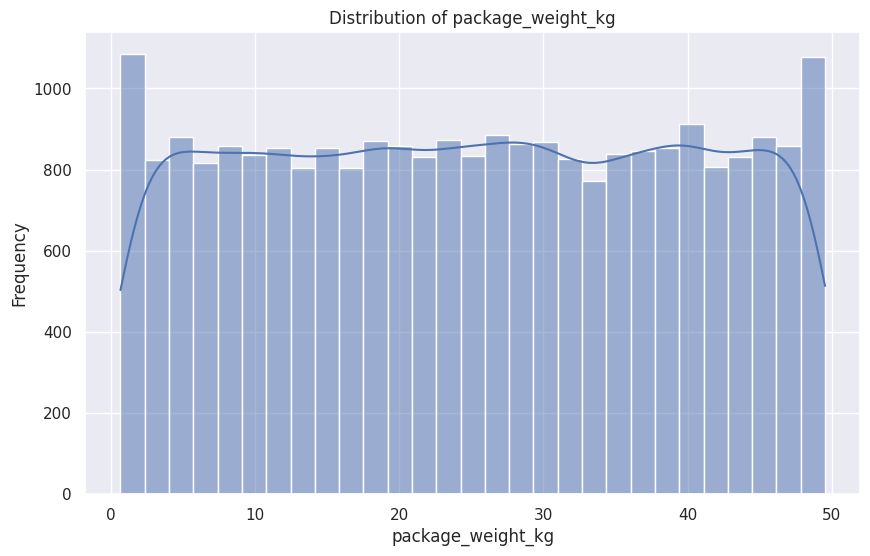

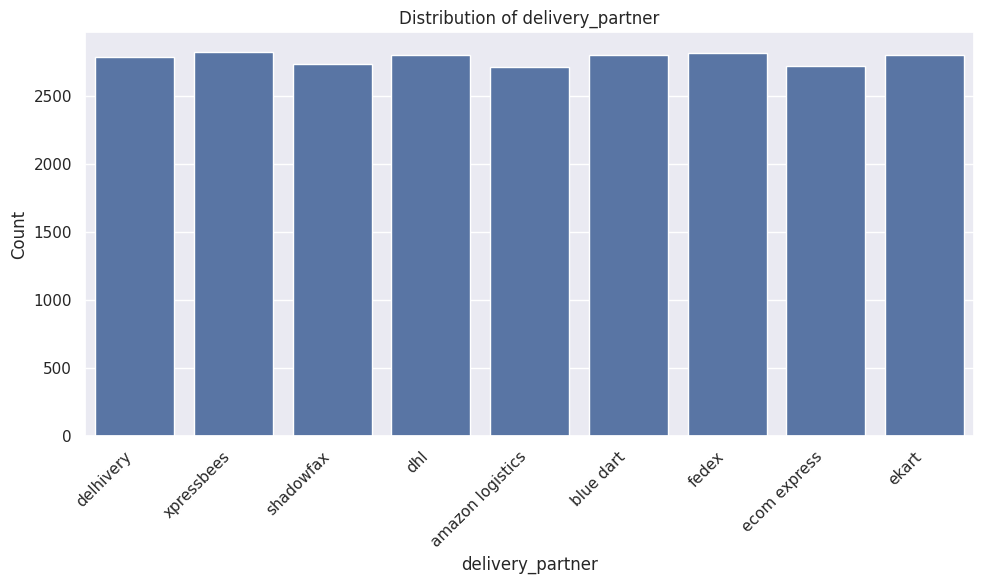

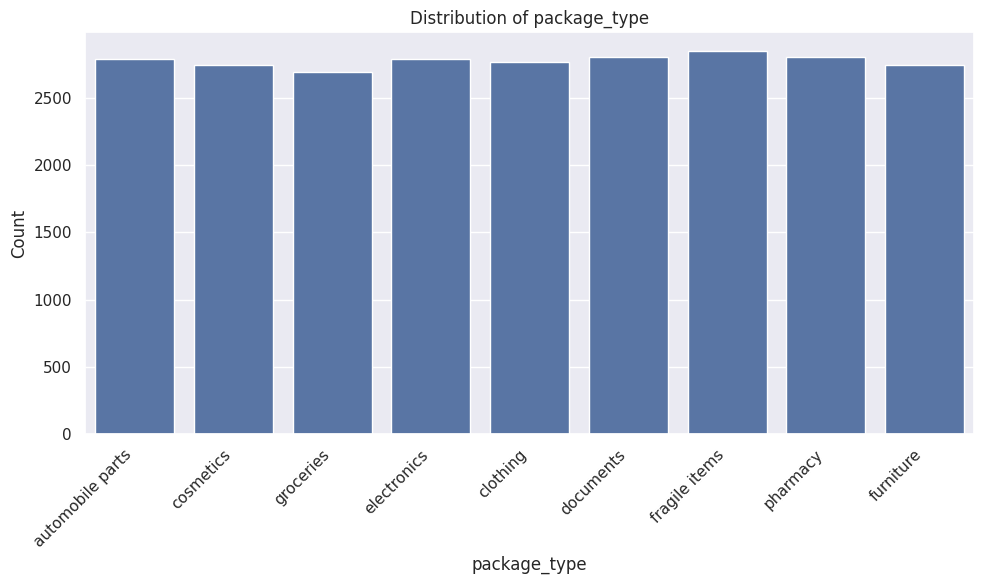

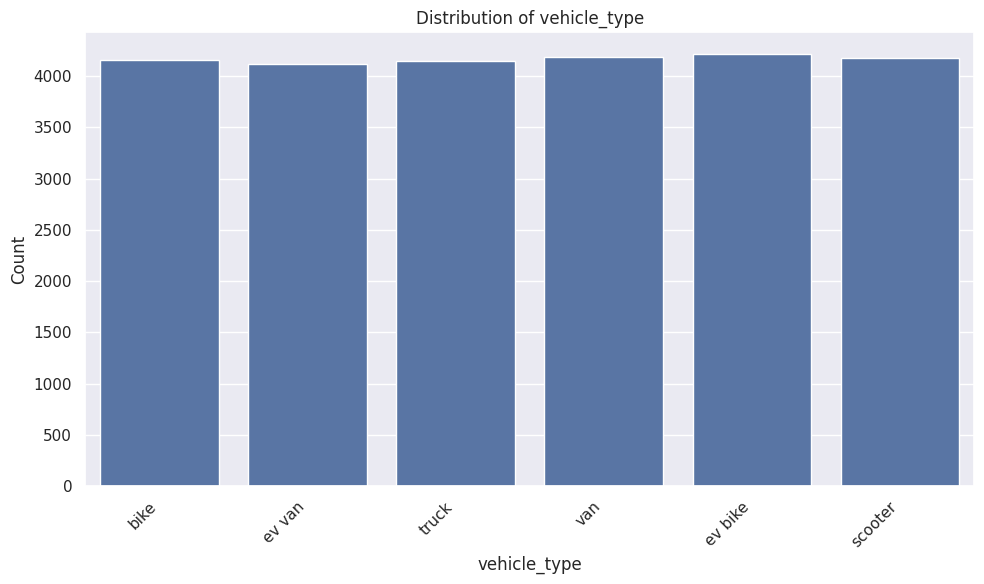

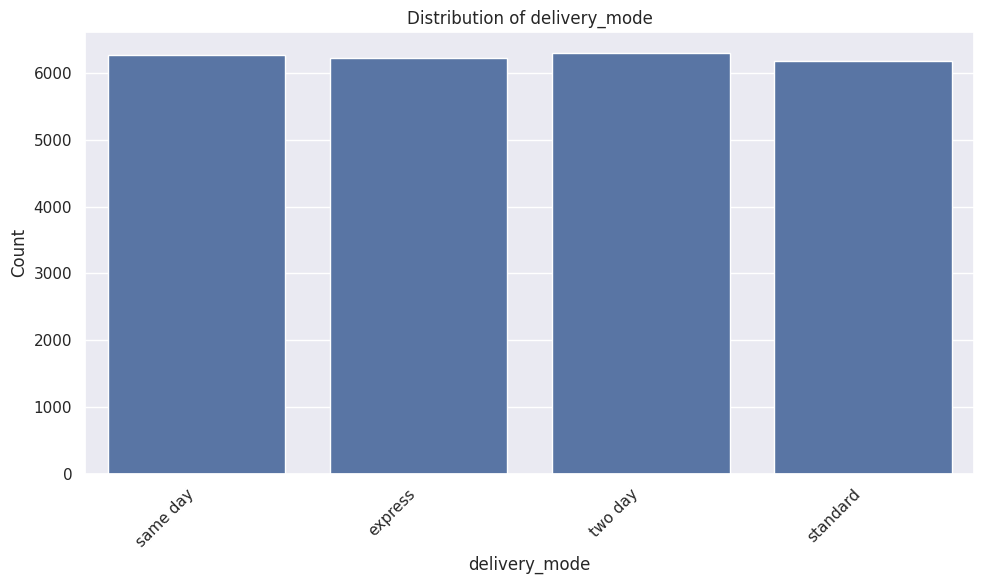

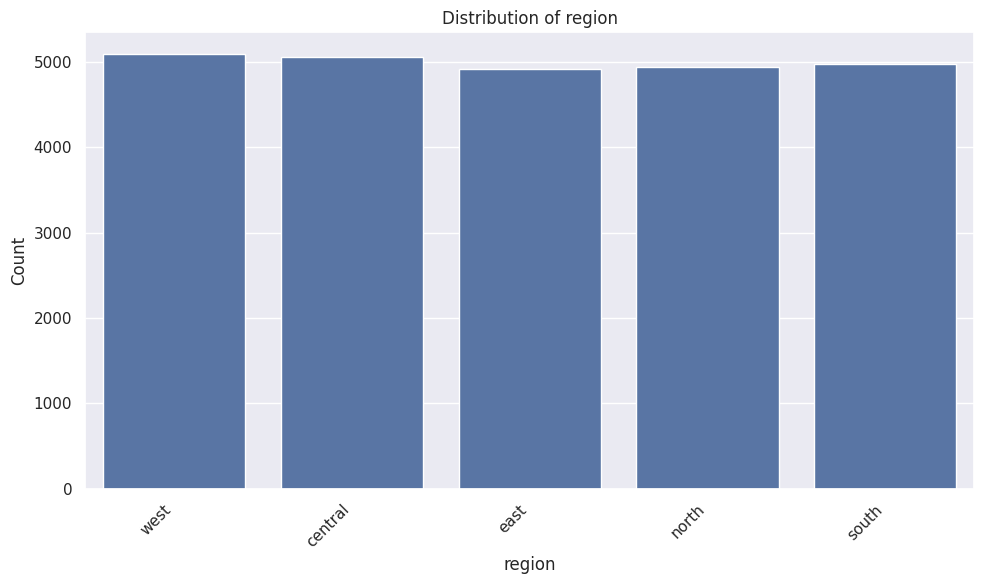

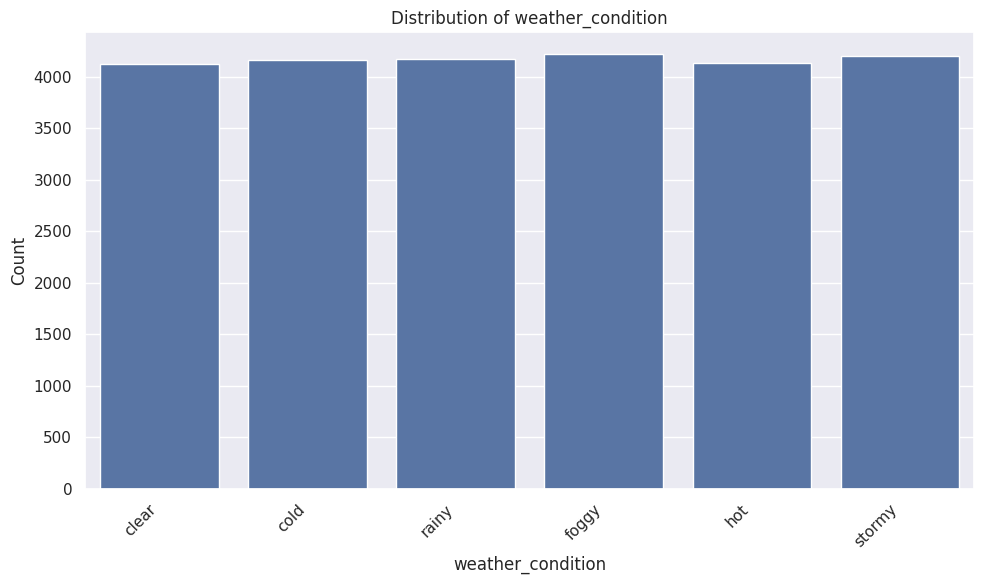

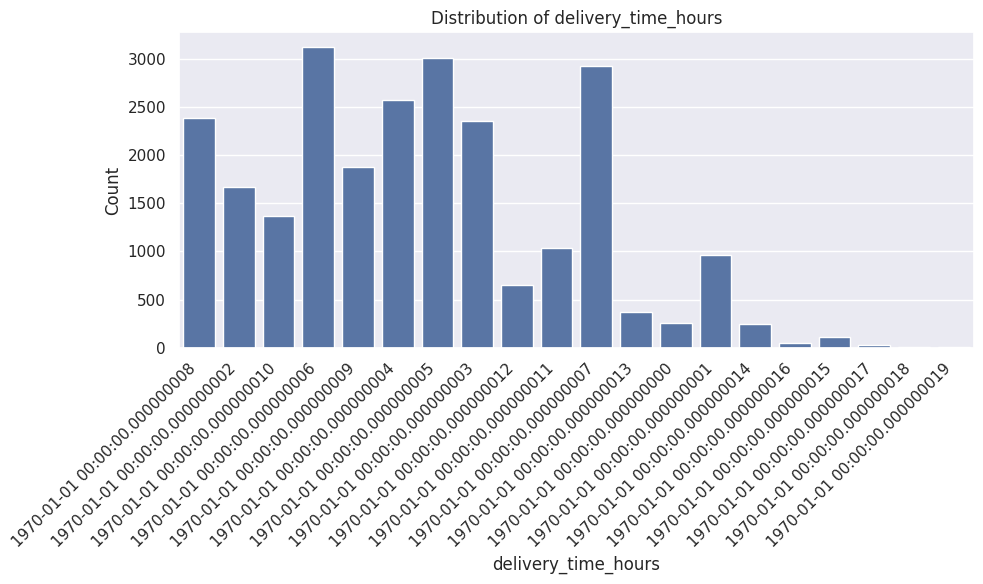

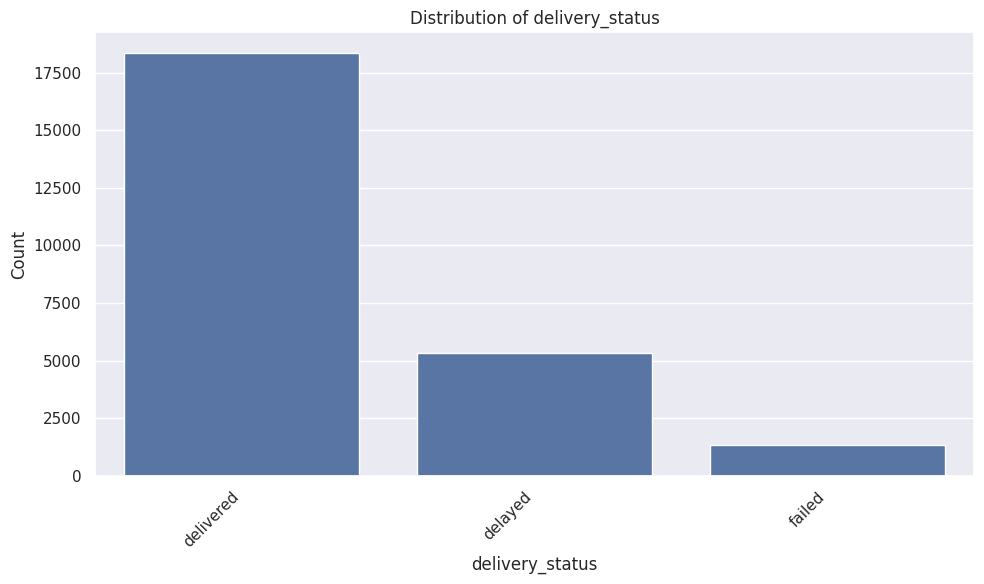

Value counts for delivery_partner:
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

Value counts for package_type:
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

Value counts for vehicle_type:
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

Value counts for delivery_mode:
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

Value counts for region:
region
west       5095
central    5060
south      4977
north      4

In [25]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

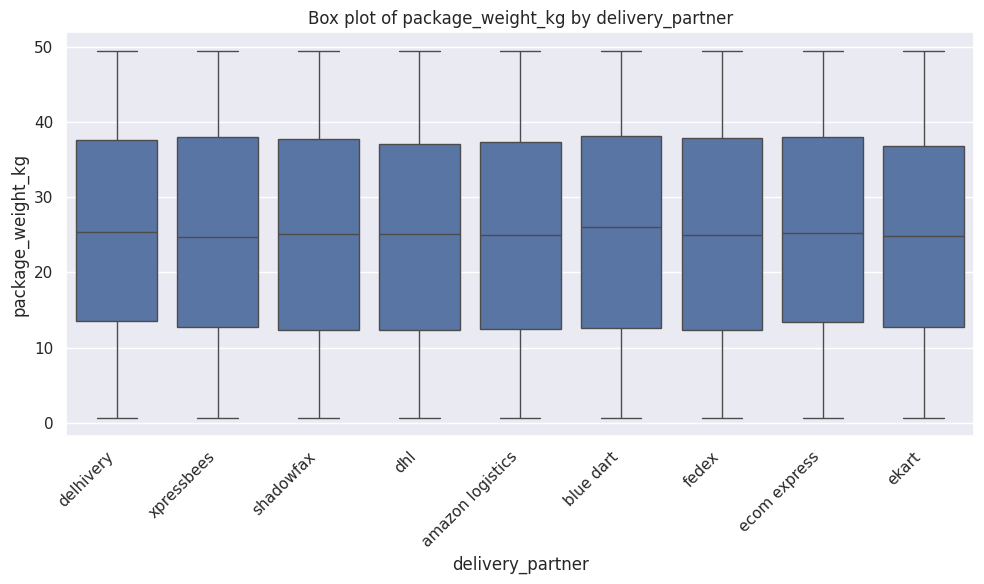

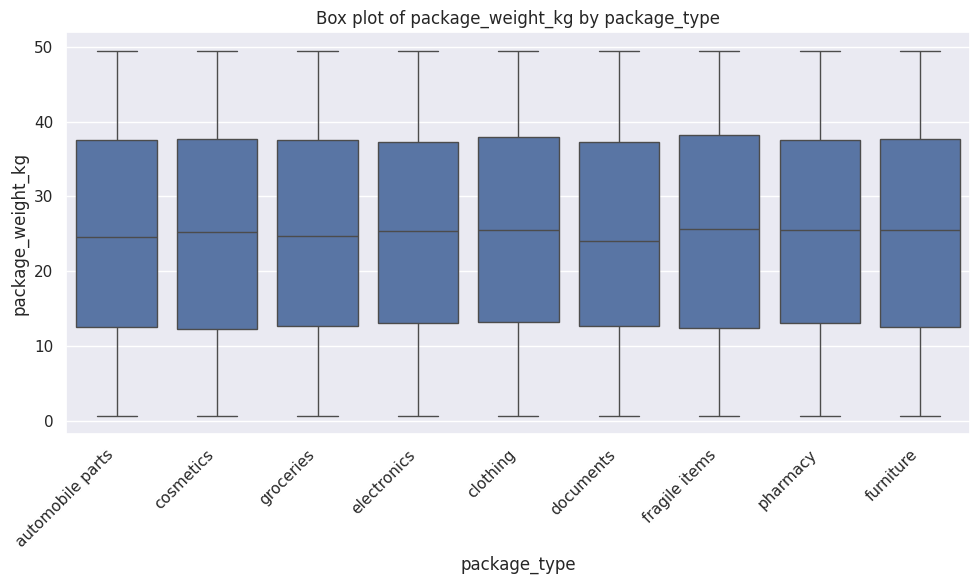

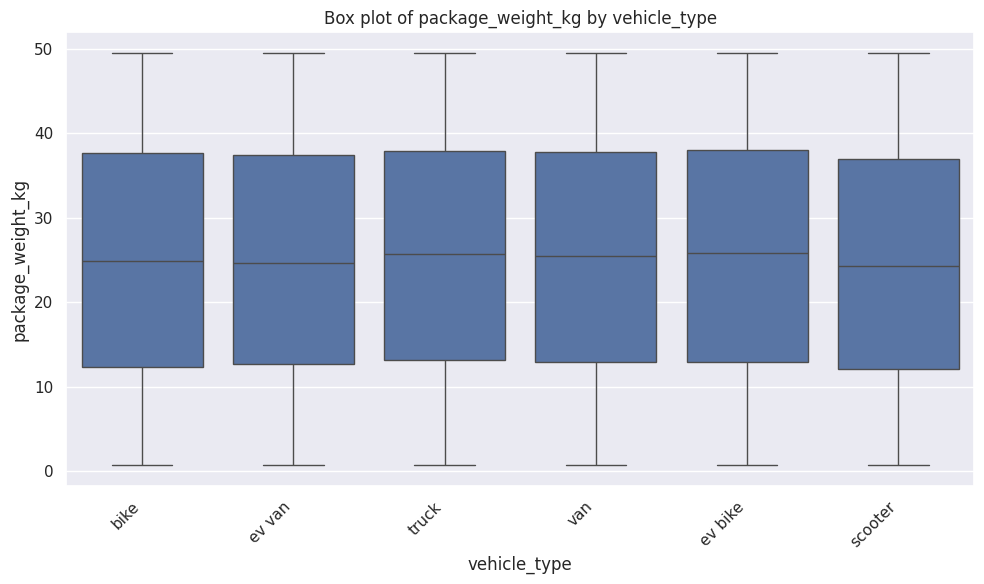

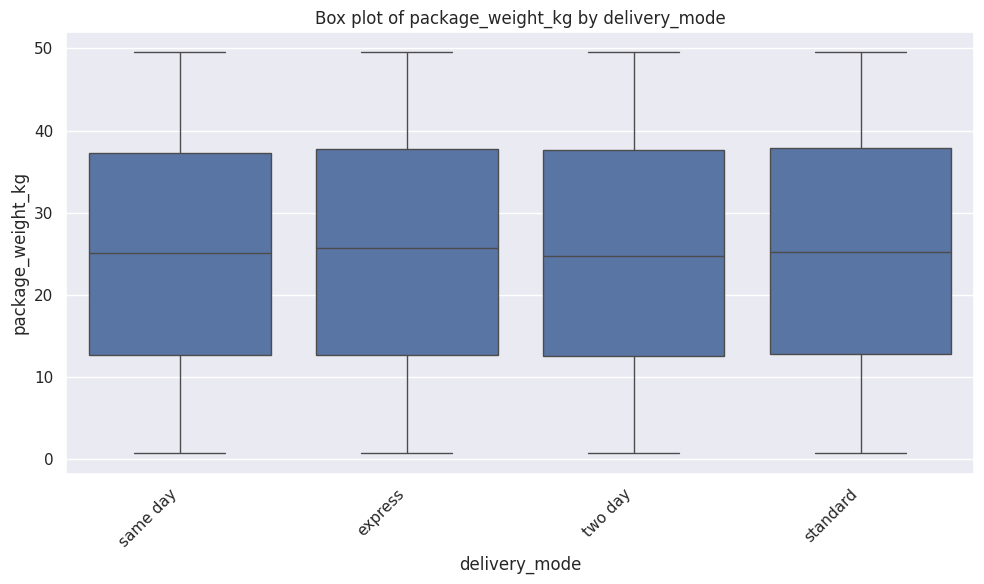

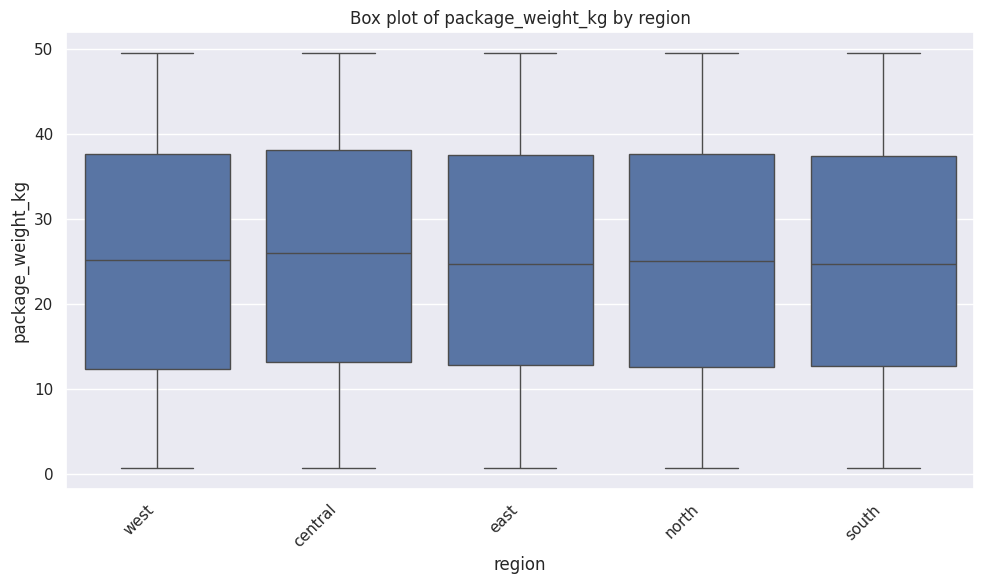

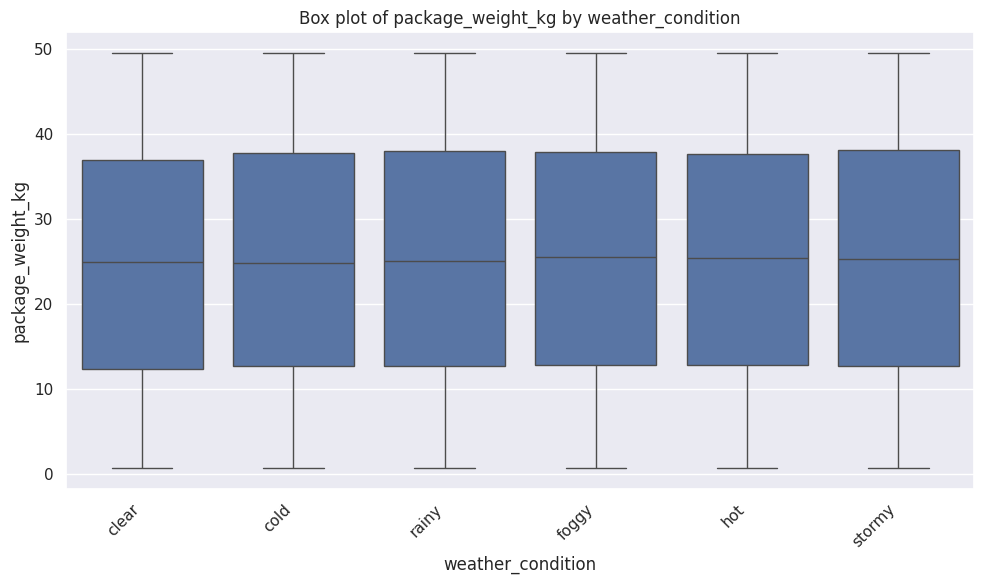

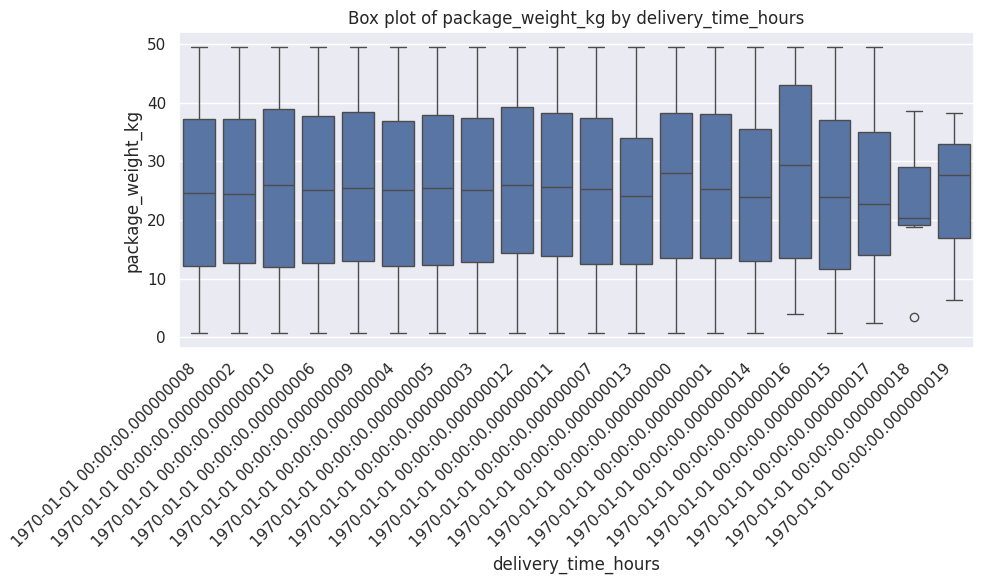

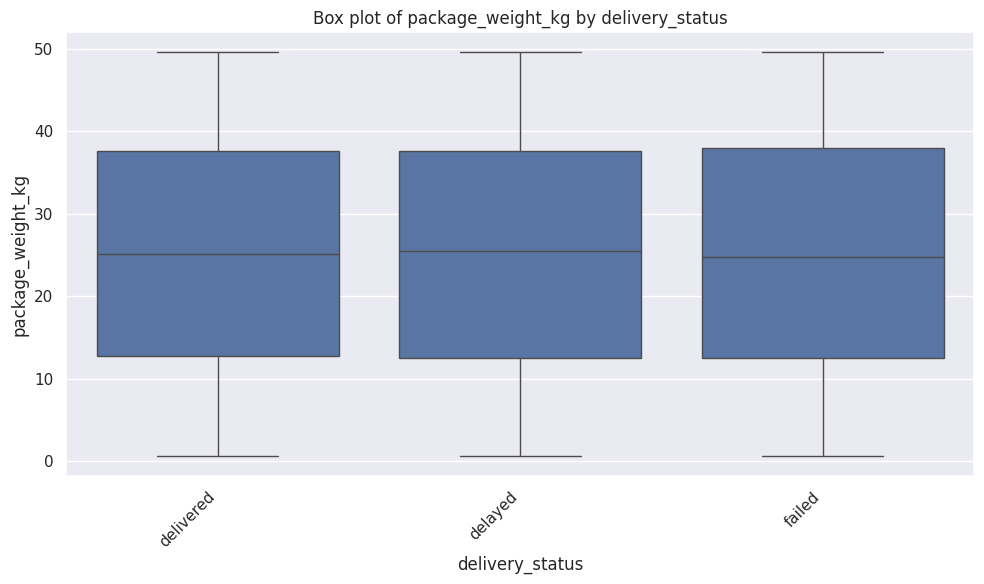

In [26]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

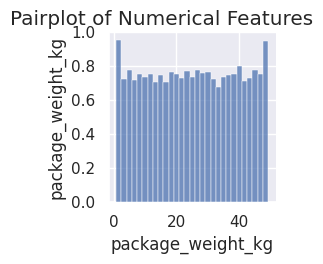

In [27]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

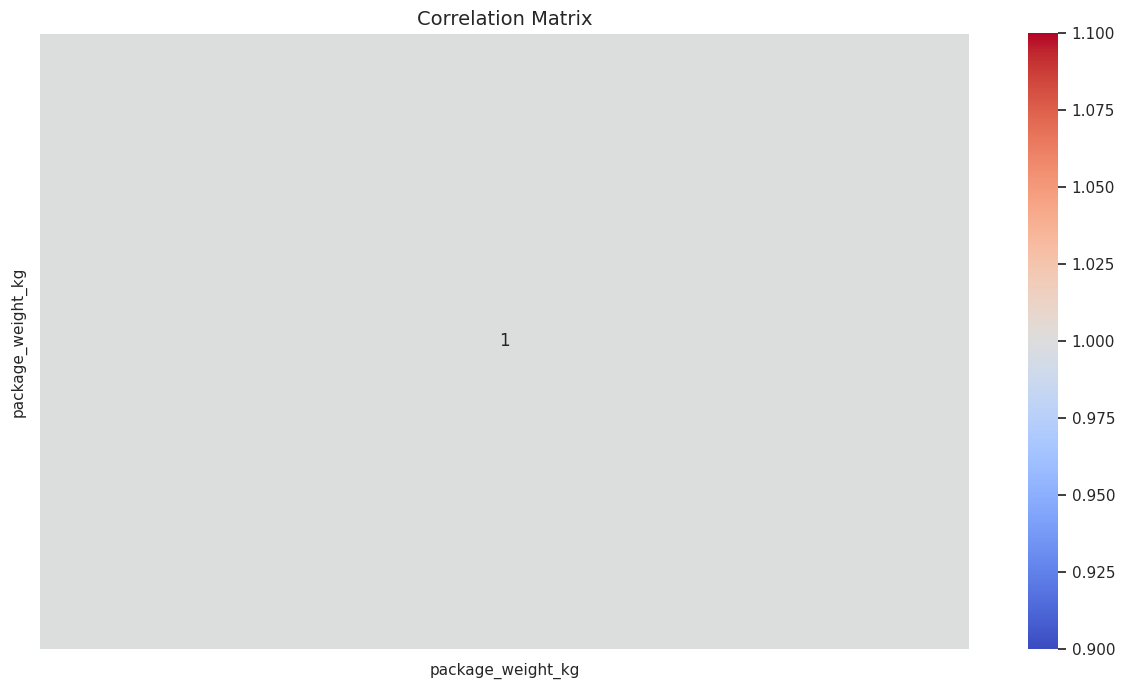

In [28]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You